# 11.3 — Global parameter sensitivity

**Question.** Which historical configuration parameters explain outcomes when all seven vary jointly? The `test` profile validates four Latin-hypercube samples and artifact plumbing; it is intentionally too small for inferential importance. Screen/full profiles run the config-defined designs and require the env-resolved real feature table. Exact counts are printed before execution.

Signed artifacts resume under the legacy sensitivity root. Optimizer seeds are averaged before Spearman and random-forest permutation importance; held-out R² diagnoses model adequacy. Scikit-learn must be installed through the project `pipeline` or `all` extra. Importance is conditional on tested bounds and is not causal or an empirical calibration.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from estonia_landuse.sensitivity.analysis import rank_parameter_importance
from estonia_landuse.sensitivity.config import DEFAULT_SEEDS, GLOBAL_SAMPLE_COUNTS
from estonia_landuse.sensitivity.plots import plot_global_importance
from estonia_landuse.sensitivity.runner import run_manifest
from estonia_landuse.sensitivity.sampling import build_global_manifest, manifest_run_count, manifest_summary

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
HISTORICAL_ROOT = PROJECT_ROOT.parent.parent if PROJECT_ROOT.parent.name == ".worktrees" else PROJECT_ROOT
# PROFILE = os.environ.get("SENSITIVITY_PROFILE", "test")
PROFILE = os.environ.get("SENSITIVITY_PROFILE", "full")
N_WORKERS = int(os.environ.get("SENSITIVITY_N_WORKERS", "12"))
OVERWRITE = os.environ.get("SENSITIVITY_OVERWRITE", "false").lower() == "true"
OUTPUT_ROOT = Path(os.environ.get("SENSITIVITY_OUTPUT_ROOT", PROJECT_ROOT / "data/processed/legacy_sensitivity")).resolve()
FEATURES_PATH = Path(os.environ.get("SENSITIVITY_FEATURES_PATH", HISTORICAL_ROOT / "data/processed/learned_carbon/features_with_forest.parquet")).resolve()
SEEDS = (0, 1) if PROFILE == "test" else DEFAULT_SEEDS[PROFILE]
N_SAMPLES = GLOBAL_SAMPLE_COUNTS[PROFILE]
OUTCOMES = ("biodiversity_gain", "carbon_gain", "cost", "changed_pct")


In [2]:
if PROFILE == "test":
    position = np.linspace(0.0, 1.0, 12)
    context = pd.DataFrame({"cell_id": np.arange(1, 13), "forest_pct": 0.35 + 0.03 * position, "wetland_pct": 0.10 + 0.02 * position, "agriculture_pct": 0.30 - 0.03 * position, "grassland_pct": 0.15 - 0.02 * position, "urban_pct": np.full(12, 0.05), "water_pct": np.full(12, 0.05), "protected_overlap_pct": 0.05 * position, "wetland_suitability": 0.2 + 0.6 * position, "opportunity_cost_proxy": 0.1 + 0.5 * position, "predicted_tco2_ha_yr": 2.5 + 2.0 * position, "peat_overlap_pct": 0.4 * position})
    feature_columns = ["wetland_suitability", "opportunity_cost_proxy"]
else:
    if not FEATURES_PATH.exists(): raise FileNotFoundError(f"Missing historical feature input: {FEATURES_PATH}")
    context = pd.read_parquet(FEATURES_PATH)
    feature_columns = [name for name in ("urban_pct", "agriculture_pct", "grassland_pct", "forest_pct", "wetland_pct", "water_pct", "naturalness_score", "carbon_score", "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy", "opportunity_cost_proxy", "rohemeeter_norm") if name in context]
    if not feature_columns: raise ValueError("No preserved Notebook 10 feature columns found")


In [3]:
manifest = build_global_manifest(profile=PROFILE, n_samples=N_SAMPLES, sampler_seed=42, scenarios=("balanced",), seeds=SEEDS)
planned_runs = manifest_run_count(manifest)
manifest_summary(manifest)
display(manifest.head(6))


global: 288 optimizer runs (profile=full)


,experiment,sample_id,scenario,seed,profile,scoring.base_change_cost,scoring.agriculture_loss_cost,scoring.max_agriculture_loss_pct,scoring.connectivity_bonus,budget_penalty_weight,max_changed_pct,constraints.wetland_suit_min_for_restore,overrides,status
0,global,global__0000,balanced,42,full,0.023188,3.391783,0.486600,0.267201,49.430116,0.274022,0.135495,{'scoring.base_change_cost': 0.023187957827542...,pending
1,global,global__0000,balanced,73,full,0.023188,3.391783,0.486600,0.267201,49.430116,0.274022,0.135495,{'scoring.base_change_cost': 0.023187957827542...,pending
2,global,global__0000,balanced,101,full,0.023188,3.391783,0.486600,0.267201,49.430116,0.274022,0.135495,{'scoring.base_change_cost': 0.023187957827542...,pending
3,global,global__0001,balanced,42,full,0.054312,5.715821,0.183826,0.274110,28.683977,0.147282,0.224268,{'scoring.base_change_cost': 0.054311830153365...,pending
4,global,global__0001,balanced,73,full,0.054312,5.715821,0.183826,0.274110,28.683977,0.147282,0.224268,{'scoring.base_change_cost': 0.054311830153365...,pending
5,global,global__0001,balanced,101,full,0.054312,5.715821,0.183826,0.274110,28.683977,0.147282,0.224268,{'scoring.base_change_cost': 0.054311830153365...,pending


In [4]:
statuses = run_manifest(context, feature_columns, manifest, OUTPUT_ROOT, PROFILE, overwrite=OVERWRITE, n_workers=min(N_WORKERS, planned_runs), progress=lambda completed, total, status: print(f"[{completed}/{total}] {status}"))
if statuses["status"].eq("failed").any(): raise RuntimeError(statuses.loc[statuses["status"].eq("failed"), ["sample_id", "seed", "error_message"]].to_string(index=False))
assert len(statuses) == planned_runs
display(statuses["status"].value_counts())


[1/288] skipped
[2/288] skipped
[3/288] skipped
[4/288] skipped
[5/288] skipped
[6/288] skipped
[7/288] skipped
[8/288] skipped
[9/288] skipped
[10/288] skipped
[11/288] skipped
[12/288] skipped
[13/288] skipped
[14/288] skipped
[15/288] skipped
[16/288] skipped
[17/288] skipped
[18/288] skipped
[19/288] skipped
[20/288] skipped
[21/288] skipped
[22/288] skipped
[23/288] skipped
[24/288] skipped
[25/288] skipped
[26/288] skipped
[27/288] skipped
[28/288] skipped
[29/288] skipped
[30/288] skipped
[31/288] skipped
[32/288] skipped
[33/288] skipped
[34/288] skipped
[35/288] skipped
[36/288] skipped
[37/288] skipped
[38/288] skipped
[39/288] skipped
[40/288] skipped
[41/288] skipped
[42/288] skipped
[43/288] skipped
[44/288] skipped
[45/288] skipped
[46/288] skipped
[47/288] skipped
[48/288] skipped
[49/288] skipped
[50/288] skipped
[51/288] skipped
[52/288] skipped
[53/288] skipped
[54/288] skipped
[55/288] skipped
[56/288] skipped
[57/288] skipped
[58/288] skipped
[59/288] skipped
[60/28

status
completed    220
skipped       68
Name: count, dtype: int64

biodiversity_gain: held-out R² = 0.433


,parameter,spearman_rho,random_forest_importance,permutation_importance_mean,permutation_importance_sd
0,scoring.agriculture_loss_cost,-0.557691,0.489322,1.228679,0.336704
1,scoring.max_agriculture_loss_pct,0.304246,0.201539,0.435764,0.200438
2,max_changed_pct,0.173142,0.082076,0.088357,0.060379
3,scoring.base_change_cost,0.148386,0.077823,0.012984,0.043545
4,budget_penalty_weight,0.076641,0.062554,-0.007049,0.024349
5,scoring.connectivity_bonus,-0.049376,0.036801,-0.007433,0.013963
6,constraints.wetland_suit_min_for_restore,-0.012344,0.049886,-0.012832,0.016778


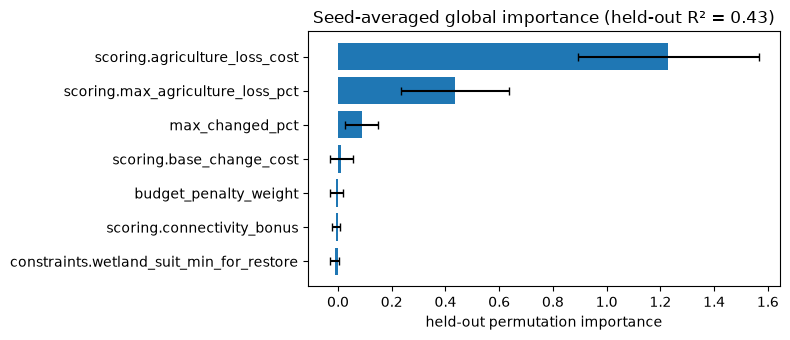

carbon_gain: held-out R² = 0.633


,parameter,spearman_rho,random_forest_importance,permutation_importance_mean,permutation_importance_sd
0,max_changed_pct,0.418530,0.608149,1.239834,0.329484
1,scoring.agriculture_loss_cost,-0.366251,0.158461,0.195681,0.092555
2,scoring.max_agriculture_loss_pct,0.115491,0.071589,0.052939,0.035061
3,budget_penalty_weight,0.170727,0.052858,0.001003,0.030116
4,constraints.wetland_suit_min_for_restore,-0.125488,0.037583,-0.004692,0.010286
5,scoring.connectivity_bonus,-0.037520,0.029327,-0.005779,0.008097
6,scoring.base_change_cost,-0.018068,0.042033,-0.018162,0.014027


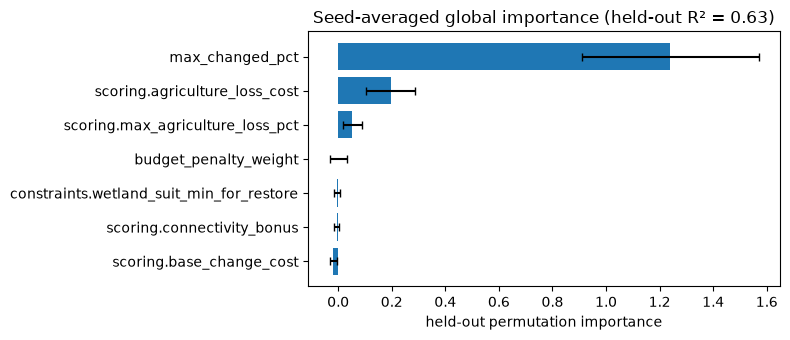

cost: held-out R² = 0.711


,parameter,spearman_rho,random_forest_importance,permutation_importance_mean,permutation_importance_sd
0,scoring.agriculture_loss_cost,0.614772,0.325943,0.679951,0.188356
1,scoring.max_agriculture_loss_pct,-0.584387,0.467380,0.480454,0.145479
2,scoring.base_change_cost,0.303025,0.087646,0.065044,0.037431
3,max_changed_pct,0.010106,0.031623,0.015443,0.007735
4,constraints.wetland_suit_min_for_restore,0.238429,0.028476,0.008994,0.007106
5,scoring.connectivity_bonus,0.067010,0.020461,-0.002003,0.004656
6,budget_penalty_weight,-0.106077,0.038472,-0.012931,0.011390


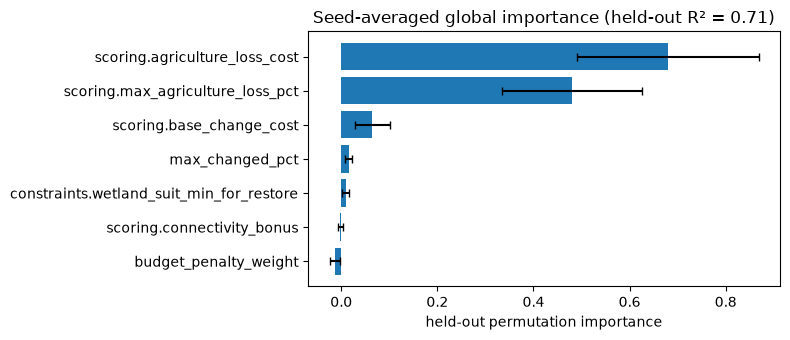

changed_pct: held-out R² = 0.715


,parameter,spearman_rho,random_forest_importance,permutation_importance_mean,permutation_importance_sd
0,max_changed_pct,0.463904,0.737116,1.350547,0.333356
1,scoring.agriculture_loss_cost,-0.313171,0.060119,0.077581,0.046478
2,scoring.max_agriculture_loss_pct,0.086747,0.044268,0.024706,0.019456
3,budget_penalty_weight,0.189392,0.041348,0.012922,0.020511
4,scoring.base_change_cost,-0.231945,0.029781,0.005111,0.004773
5,constraints.wetland_suit_min_for_restore,-0.220022,0.059367,-0.006874,0.025999
6,scoring.connectivity_bonus,-0.087683,0.028001,-0.010806,0.008698


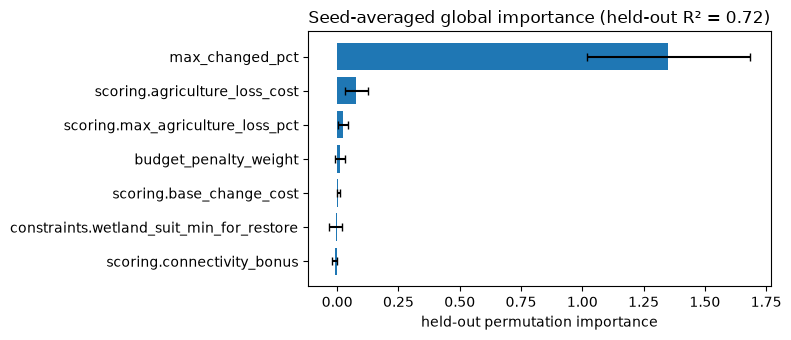

In [5]:
metrics = pd.concat([pd.read_parquet(path) for path in statuses["metrics_path"]], ignore_index=True)
if metrics["sample_id"].nunique() < 8:
    print("Test profile completed; at least eight parameter samples are required for held-out importance.")
else:
    for outcome in OUTCOMES:
        ranked = rank_parameter_importance(metrics, outcome)
        print(f"{outcome}: held-out R² = {ranked.attrs['held_out_r2']:.3f}")
        display(ranked)
        figure, _ = plot_global_importance(ranked)
        display(figure)
        plt.close(figure)
